In [1]:
import BESplotting as bp

import functions as fn
from mastu import HSV
import matplotlib.pyplot as plt
import my_funcs as mf
import numpy as np
import sys

%matplotlib widget

kk_cz couldnt be imported
dd couldnt be imported


In [2]:
import plotFunctions as pf
from matplotlib.ticker import AutoMinorLocator

def plotN(twant, xlim=[1.25,1.575]):
    I = fn.findNearest(time, twant)

    fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
    ax.plot(Rprofile, neutralDensity[I], c='C2')
    ax.fill_between(
        Rprofile, neutralDensity[I]-neutralErr[I], 
        neutralDensity[I]+neutralErr[I], color='C2', alpha=0.3
    )
    ax.set_xlim(xlim)
    ax.set_yscale('log')
    # ylim = ax.get_ylim()
    # ylim[0] = 1e14
    ylim = [1e14, ax.get_ylim()[1]]
    ax.set_ylim(ylim)
    ax.fill_between(
        [RendThomson[I],xlim[1]], [ylim[0],ylim[0]], 
        [ylim[1],ylim[1]], color='k', alpha=0.1
    )

    ax.set_xlabel('$R$ (m)', fontsize=9)
    ax.set_ylabel('$n_0$ (m$^{-3}$)', fontsize=9)
    ax.set_title(f't={twant:.4f}s', fontsize=9)
    ax.tick_params(
        axis="both", which='both', labelsize=9, direction='in', 
        left=True, bottom=True, right=True, top=True
    )
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.get_offset_text().set_size(9)

    plt.tight_layout()
    
    return

def inversion(twant, npz):
    ### load the results
    R = results['R']
    data = results['data']
    err = results['err']
    mask = results['mask']
    time = results['time']
    RgridB = results['RgridB']
    emissivity = results['emissivity']
    emissivityErr = results['emissivityErr']
    backprojection = results['backprojection']
    emMax = results['emMax']
    emMaxR = results['emMaxR']
    emR0 = results['emR0']
    emR1 = results['emR1']
    emFWHM = results['emFWHM']
    emFWHMerr = results['emFWHMerr']
    
    I = pf.findNearest(time, twant)
    J = I + 1
            
    fills = pf.makeFills(mask, R)
    ### call the plotting function
    pf.plotInversion(
        R, data[I:J], err[I:J], RgridB, emissivity[I:J], 
        emissivityErr[I:J], backprojection[I:J], time[I:J], emMaxR[I:J], 
        emMax[I:J], emR0[I:J], emR1[I:J], emFWHM[I:J], emFWHMerr[I:J], 
        fills[I:J], savePath=None, close=False
    )
    return


def result(twant, npz):
    ### load the results
    Rprofile = results['Rprofile']
    time = results['time']
    emissivity = results['emissivity']
    emissivityErr = results['emissivityErr']
    emMax = results['emMax']
    emMaxR = results['emMaxR']
    emR0 = results['emR0']
    emR1 = results['emR1']
    emFWHM = results['emFWHM']
    emFWHMerr = results['emFWHMerr']
    Rind = results['Rind']
    RendThomson = results['RendThomson']
    ioniseRate = results['ioniseRate']
    ioniseErr = results['ioniseErr']
    neutralDensity = results['neutralDensity']
    neutralErr = results['neutralErr']
    ioniseMax = results['ioniseMax']
    ioniseMaxR = results['ioniseMaxR']
    ioniseR0 = results['ioniseR0']
    ioniseR1 = results['ioniseR1']
    ioniseFWHM = results['ioniseFWHM']
    ioniseFWHMerr = results['ioniseFWHMerr']
    neutralMax = results['neutralMax']
    neutralMaxR = results['neutralMaxR']
    neutralR1 = results['neutralR1']
    neutralR2 = results['neutralR2']
    neutralR3 = results['neutralR3']
    neutralWidth1 = results['neutralWidth1']
    neutralWidth1err = results['neutralWidth1err']
    neutralWidth2 = results['neutralWidth2']
    neutralWidth2err = results['neutralWidth2err']
    neutralWidth3 = results['neutralWidth3']
    neutralWidth3err = results['neutralWidth3err']
    neutralR1A = results['neutralR1A']
    neutralR2A = results['neutralR2A']
    neutralR3A = results['neutralR3A']
    R = results['R']
    mask = results['mask']
    figN0 = results['figN0']
    psiN = results['psiN']
    neutralRatio = results['neutralRatio']
    
    I = pf.findNearest(time, twant)
    J = I + 1
            
    fills = pf.makeFills(mask, R)
    ### call the plotting function
    pf.plotResults(
        Rprofile, emissivity[I:J,Rind:], emissivityErr[I:J,Rind:], 
        emMaxR[I:J], emMax[I:J], emR0[I:J], emR1[I:J], emFWHM[I:J], 
        emFWHMerr[I:J], ioniseRate[I:J], ioniseErr[I:J], ioniseMax[I:J], 
        ioniseMaxR[I:J], ioniseR0[I:J], ioniseR1[I:J], ioniseFWHM[I:J], 
        ioniseFWHMerr[I:J], neutralDensity[I:J], neutralErr[I:J], 
        neutralMax[I:J], neutralMaxR[I:J], neutralR1[I:J], neutralR2[I:J], 
        neutralR3[I:J], neutralWidth1[I:J], neutralWidth1err[I:J], 
        neutralWidth2[I:J], neutralWidth2err[I:J], neutralWidth3[I:J], 
        neutralWidth3err[I:J], neutralR1A[I:J], neutralR2A[I:J], 
        neutralR3A[I:J], RendThomson[I:J], time[I:J], fills[I:J], 
        figN0=figN0[I:J], neutralRatio=neutralRatio[I:J], psiN=psiN[I:J], 
        savePath=None, close=False
    )
    return

In [3]:
shotn = 51347
resultsFile = f'/home/sthoma/Documents/Results/rba/{shotn}/rba_results_neutral.npz'

In [4]:
results = np.load(resultsFile)
results.files

['R',
 'data',
 'err',
 'time',
 'Rgrid',
 'RgridB',
 'emissivity',
 'emissivityErr',
 'backprojection',
 'scale',
 'emMax',
 'emMaxR',
 'emR0',
 'emR1',
 'emFWHM',
 'emFWHMerr',
 'Rind',
 'Rprofile',
 'profileTemp',
 'profileDensity',
 'RendThomson',
 'ioniseRate',
 'ioniseErr',
 'neutralDensity',
 'neutralErr',
 'ioniseMax',
 'ioniseMaxR',
 'ioniseR0',
 'ioniseR1',
 'ioniseFWHM',
 'ioniseFWHMerr',
 'neutralMax',
 'neutralMaxR',
 'neutralR1',
 'neutralR2',
 'neutralR3',
 'neutralWidth1',
 'neutralWidth1err',
 'neutralWidth2',
 'neutralWidth2err',
 'neutralWidth3',
 'neutralWidth3err',
 'neutralR1A',
 'neutralR2A',
 'neutralR3A',
 'neutralWidth1A',
 'neutralWidth1Aerr',
 'neutralWidth2A',
 'neutralWidth2Aerr',
 'neutralWidth3A',
 'neutralWidth3Aerr',
 'figN0',
 'psiN',
 'neutralRatio',
 'invert_version',
 'neutral_version',
 'mask']

In [6]:
results = np.load(resultsFile)

R = results['R']
# data = results['data']
# err = results['err']
time = results['time']
# Rgrid = results['Rgrid']
RgridB = results['RgridB']
# emissivity = results['emissivity']
# emissivityErr = results['emissivityErr']
# backprojection = results['backprojection']
# scale = results['scale']
emMax = results['emMax']
emMaxR = results['emMaxR']
# emR0 = results['emR0']
# emR1 = results['emR1']
emFWHM = results['emFWHM']
emFWHMerr = results['emFWHMerr']
# Rind = results['Rind']
Rprofile = results['Rprofile']
profileTemp = results['profileTemp']
profileDensity = results['profileDensity']
RendThomson = results['RendThomson']
# ioniseRate = results['ioniseRate']
# ioniseErr = results['ioniseErr']
neutralDensity = results['neutralDensity']
neutralErr = results['neutralErr']
ioniseMax = results['ioniseMax']
ioniseMaxR = results['ioniseMaxR']
# ioniseR0 = results['ioniseR0']
# ioniseR1 = results['ioniseR1']
ioniseFWHM = results['ioniseFWHM']
ioniseFWHMerr = results['ioniseFWHMerr']
neutralMax = results['neutralMax']
neutralMaxR = results['neutralMaxR']
# neutralR1 = results['neutralR1']
# neutralR2 = results['neutralR2']
# neutralR3 = results['neutralR3']
neutralWidth1 = results['neutralWidth1']
neutralWidth1err = results['neutralWidth1err']
neutralWidth2 = results['neutralWidth2']
neutralWidth2err = results['neutralWidth2err']
neutralWidth3 = results['neutralWidth3']
neutralWidth3err = results['neutralWidth3err']
# neutralR1A = results['neutralR1A']
# neutralR2A = results['neutralR2A']
# neutralR3A = results['neutralR3A']
# neutralWidth1A = results['neutralWidth1A']
# neutralWidth1Aerr = results['neutralWidth1Aerr']
# neutralWidth2A = results['neutralWidth2A']
# neutralWidth2Aerr = results['neutralWidth2Aerr']
# neutralWidth3A = results['neutralWidth3A']
# neutralWidth3Aerr = results['neutralWidth3Aerr']
figN0 = results['figN0']
psiN = results['psiN']
neutralRatio = results['neutralRatio']

In [7]:
textFile = f'/home/sthoma/Documents/Results/rba/{shotn}/rba_results_neutral.txt'
resultsDict = fn.loadDict(textFile)
resultsDict

{'shotn': 51347,
 'Rzfile': '/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/51267_684.npz',
 'maskFile': '/home/sthoma/tokamak_inversion_routines/mastu/Masks/51267_684_bigmask.npy',
 'I0': 244,
 'I1': 245,
 'J0': 59,
 'J1': 236,
 'tend': 706,
 'raverage': 0,
 'taverage': 1,
 'T0': 180,
 'T1': 650,
 'saveFile': 'rba_results.npz',
 'photons': 1,
 'mPhotons': 7527200000000.0,
 'mPhotonsErr': 5500000000.0,
 'vignette': 1,
 'x0': 0,
 'x1': 1023,
 'dx': 1,
 'y0': 0,
 'y1': 1023,
 'dy': 1,
 'xc': 519.195,
 'yc': 500.687,
 'wx': 140.377,
 'wy': 140.257,
 'shape': 0.19405,
 'amp': 152.067,
 'offset': 121.7288,
 'rEnd': 1.525,
 'nrMult': 2.5,
 'sysErr': 5,
 'photon': 1,
 'biasedEdges': 1,
 'nFisher': 4,
 'regGuess': 0.7,
 'regMin': 0.4,
 'kindThomson': 'fit',
 'Rprofile0': 1.25,
 'line': 'dalpha',
 'kindExcite': 'cubic',
 'kindRecomb': 'cubic',
 'kindIonise': 'linear',
 'percent': 0.1,
 'figTemp': 300.0,
 'invert_version': '2.2.0',
 'neutral_version': '2.2.0'}

In [8]:
dar, dat = mf.getDalpha(shotn)
daUOSP, daUSXD, daLOSP, daLSXD = mf.getDalphaDivertor(shotn)

loading radial D-alpha
loaded /XIM/DA/HM10/R
loading tangential D-alpha
loaded /XIM/DA/HM10/T
loading upper OSP D-alpha
loaded /XIM/DA/HU10/OSP
loading upper SXD D-alpha
loaded /XIM/DA/HU10/SXD
loading lower OSP D-alpha
loaded /XIM/DA/HL02/OSP
loading upper SXD D-alpha
loaded /XIM/DA/HL02/SXD


In [9]:
time[0], time[-1]

(0.18001299999999998, 0.649013)

In [10]:
t0 = 0.10
t1 = 0.72

In [11]:
def makeMask(tELMs, time, before=2e-3, after=5e-3):
    
    mask = np.ones_like(time).astype(bool)
    
    
    for i in range(0, len(tELMs)):
        twant = tELMs[i]
        t0 = fn.findNearest(time, twant-before)
        t1 = fn.findNearest(time, twant+after)+1
        mask[t0:t1] = False
        
        
    return mask

In [12]:
ionb00 = ioniseMaxR > RendThomson
n0boo = neutralMaxR > RendThomson

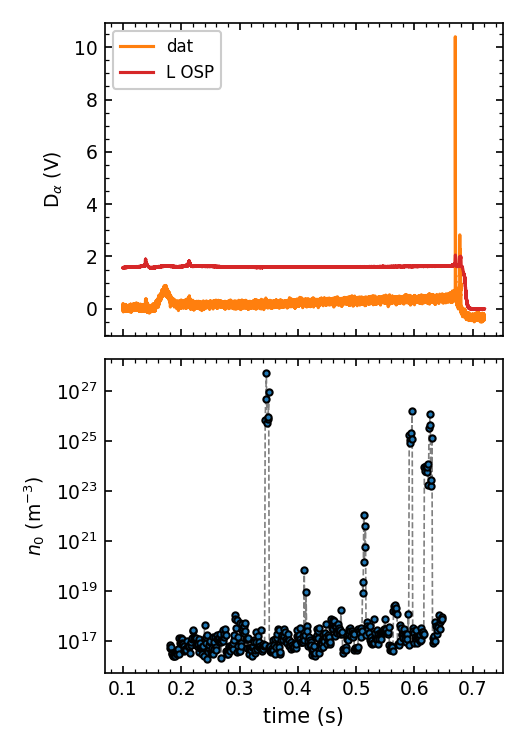

In [14]:


### make the cut down dalpha data
### time base
xalpha = daLOSP.time.data
dtAlpha = np.mean(np.diff(xalpha))
### find the time range and chop it down
tA = fn.findNearest(xalpha, t0)
tB = fn.findNearest(xalpha, t1)
### chop it down
xalpha = daLOSP.time.data[tA:tB]
yalpha = daLOSP.data[tA:tB]


### find the ELMs
bi, uc = mf.blob_detector(yalpha, mult=2.5, sep='limit')
tELMs = xalpha[bi]

### specify the time before and after the ELM to exclude
before = 2e-3
after = 5e-3
### indices for plotting dalpha
beforeAlpha = int(before / dtAlpha)
afterAlpha = int(after / dtAlpha)

### make the dAlpha mask
maskAlpha = makeMask(tELMs, xalpha, before=before, after=after)


### chopped down the neutral data 
tind0 = fn.findNearest(time, t0)
tind1 = fn.findNearest(time, t1)
### 
xn0 = time[tind0:tind1]
dtn0 = np.mean(np.diff(time))
yn0 = neutralMax[tind0:tind1]
### indices for plotting n0
# beforen0 = int(before / dtn0)
# aftern0 = int(after / dtn0)
### make the n0 mask
maskn0 = makeMask(tELMs, xn0, before, after)


### plot the data
fig, ax = plt.subplots(2, 1, figsize=(3.5,5), dpi=150, sharex=True)

### dalpha
# ax[0].plot(dar.time.data[tA:tB], dar.data[tA:tB]*8., c='C0', label='dar')
ax[0].plot(dat.time.data[tA:tB], dat.data[tA:tB]*40., c='C1', label='dat')
# ax[0].plot(daUOSP.time.data[tA:tB], daUOSP.data[tA:tB], c='C4', label='U OSP')
# ax[0].plot(daUSXD.time.data[tA:tB], daUSXD.data[tA:tB], c='C5', label='U SXD')
# ax[0].plot(daLSXD.time.data[tA:tB], daLSXD.data[tA:tB], c='C6', label='L SXD')
ax[0].plot(xalpha, yalpha, c='C3', label='L OSP')
# ax[0].plot(xalpha[maskAlpha], yalpha[maskAlpha], '.', c='C0')
ax[0].plot(tELMs, yalpha[bi], 'v', c='C2', mec='k')
### limit
xlim0 = ax[0].get_xlim()
ylim0 = ax[0].get_ylim()
ax[0].set_xlim(xlim0)
ax[0].set_ylim(ylim0)
### ELM fillbetween
for i in range(0, len(bi)):
    x0 = xalpha[bi[i]-beforeAlpha]
    x1 = xalpha[bi[i]+afterAlpha]
    ax[0].fill_between([x0,x1], [ylim0[0],ylim0[0]], [ylim0[1],ylim0[1]], color='C2', alpha=0.4)
### some options
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].legend(fancybox=1, framealpha=1, fontsize=8)
# ax[0].set_xlabel('time (s)')
ax[0].set_ylabel('D$_\\alpha$ (V)', fontsize=9)

### n0
ax[1].plot(xn0, yn0, '--', c='gray', lw=0.8)
ax[1].plot(xn0[maskn0], yn0[maskn0], '.', c='C0', mec='k')
### limit
ax[1].set_yscale('log')
xlim1 = ax[1].get_xlim()
ylim1 = ax[1].get_ylim()
ax[1].set_xlim(xlim1)
ax[1].set_ylim(ylim1)
# ### ELM fillbetween
for i in range(0, len(bi)):
    x0 = xalpha[bi[i]-beforeAlpha]
    x1 = xalpha[bi[i]+afterAlpha]
    ax[1].fill_between([x0,x1], [ylim1[0],ylim1[0]], [ylim1[1],ylim1[1]], color='C2', alpha=0.4)
### some options
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].set_xlabel('time (s)')
ax[1].set_ylabel('$n_0$ (m$^{-3}$)', fontsize=9)


plt.tight_layout()

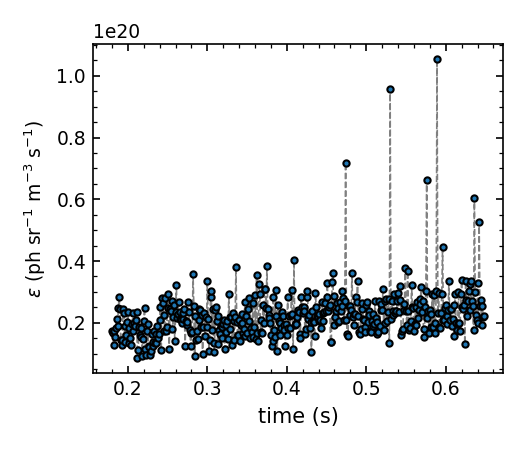

In [17]:
yEm = emMax[tind0:tind1]

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)

### n0
ax.plot(xn0, yEm, '--', c='gray', lw=0.8)
ax.plot(xn0[maskn0], yEm[maskn0], '.', c='C0', mec='k')
### limit
# ax.set_yscale('log')
xlim1 = ax.get_xlim()
ylim1 = ax.get_ylim()
ax.set_xlim(xlim1)
ax.set_ylim(ylim1)
# ### ELM fillbetween
for i in range(0, len(bi)):
    x0 = xalpha[bi[i]-beforeAlpha]
    x1 = xalpha[bi[i]+afterAlpha]
    ax.fill_between([x0,x1], [ylim1[0],ylim1[0]], [ylim1,ylim1], color='C2', alpha=0.4)
### some options
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlabel('time (s)')
ax.set_ylabel('$\\epsilon$ (ph sr$^{-1}$ m$^{-3}$ s$^{-1}$)', fontsize=9)

plt.tight_layout()

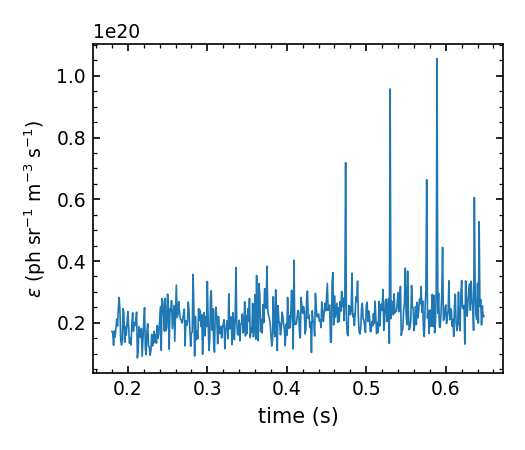

In [19]:
yEm = emMax[tind0:tind1]

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)

### n0
# ax.plot(xn0, yEm, '--', c='gray', lw=0.8)
# ax.plot(xn0[maskn0], yEm[maskn0], '.', c='C0', mec='k')
ax.plot(xn0, yEm, '-', c='C0', lw=0.8)
### limit
# ax.set_yscale('log')
xlim1 = ax.get_xlim()
ylim1 = ax.get_ylim()
ax.set_xlim(xlim1)
ax.set_ylim(ylim1)
# ### ELM fillbetween
for i in range(0, len(bi)):
    x0 = xalpha[bi[i]-beforeAlpha]
    x1 = xalpha[bi[i]+afterAlpha]
    ax.fill_between([x0,x1], [ylim1[0],ylim1[0]], [ylim1,ylim1], color='C2', alpha=0.4)
### some options
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlabel('time (s)')
ax.set_ylabel('$\\epsilon$ (ph sr$^{-1}$ m$^{-3}$ s$^{-1}$)', fontsize=9)

plt.tight_layout()

/tmp/ipykernel_21489/1531044576.py:35: UserWarning: AutoMinorLocator does not work with logarithmic scale
  plt.tight_layout()
/home/sthoma/.local/lib/python3.9/site-packages/ipympl/backend_nbagg.py:336: UserWarning: AutoMinorLocator does not work with logarithmic scale
  self.figure.savefig(buf, format='png', dpi='figure')


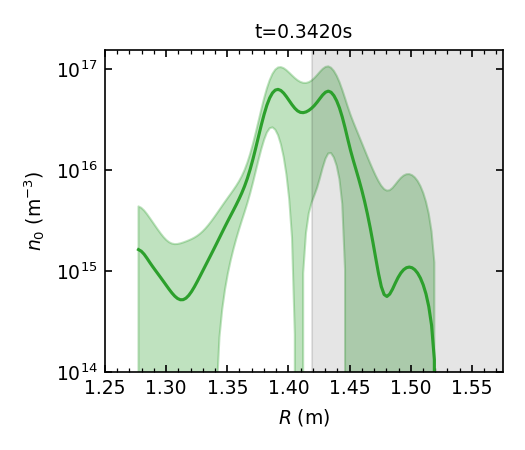

In [14]:
twant = 0.342
plotN(twant)

/tmp/ipykernel_21489/1531044576.py:35: UserWarning: AutoMinorLocator does not work with logarithmic scale
  plt.tight_layout()


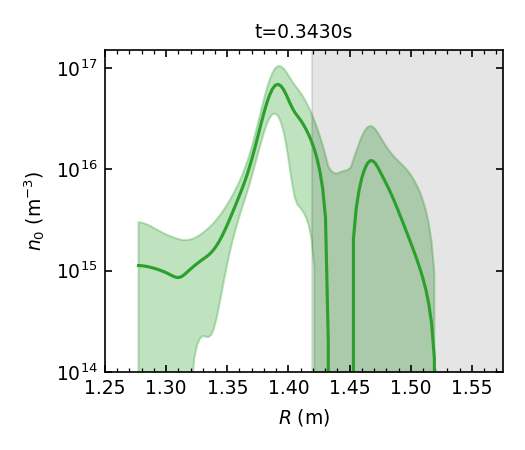

In [15]:
twant = 0.343
plotN(twant)

/tmp/ipykernel_21489/1531044576.py:35: UserWarning: AutoMinorLocator does not work with logarithmic scale
  plt.tight_layout()


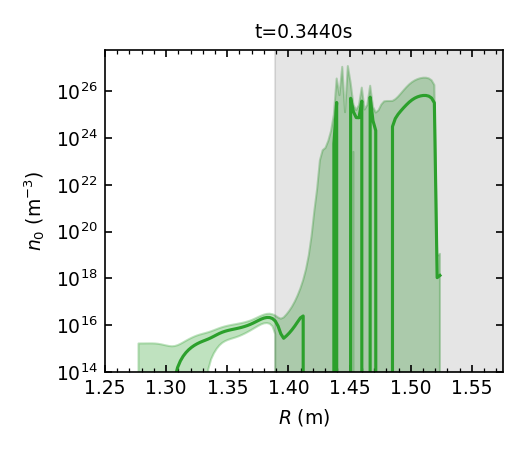

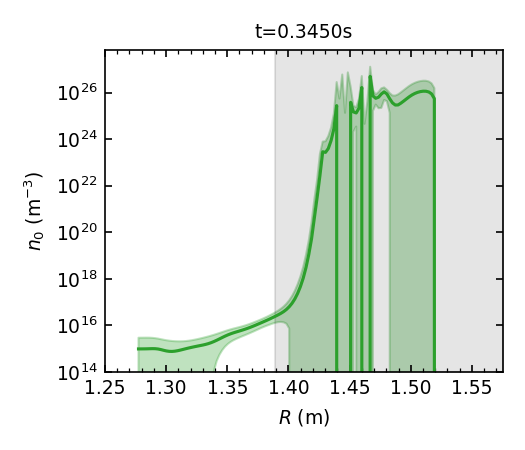

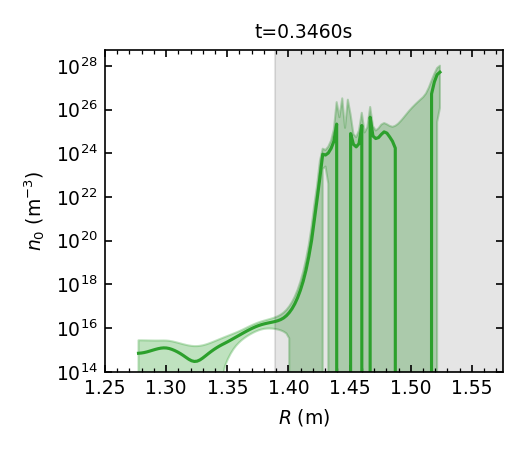

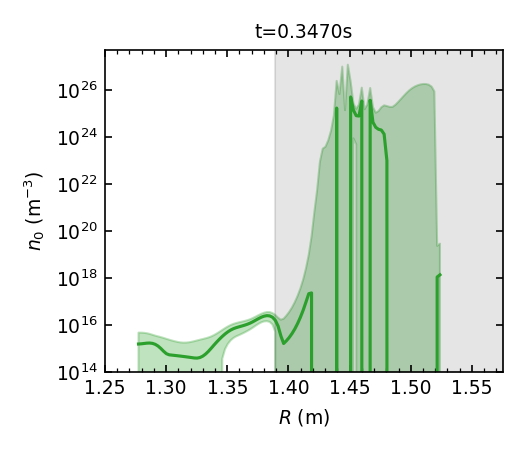

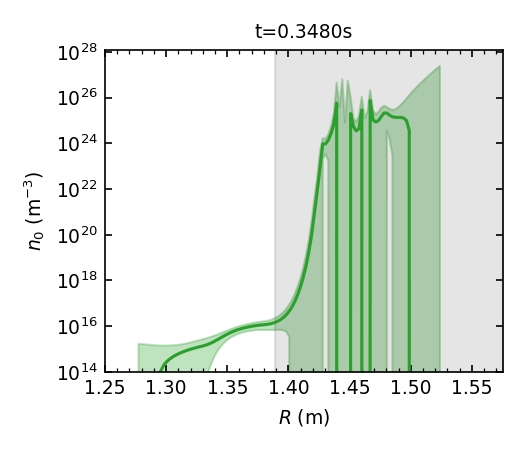

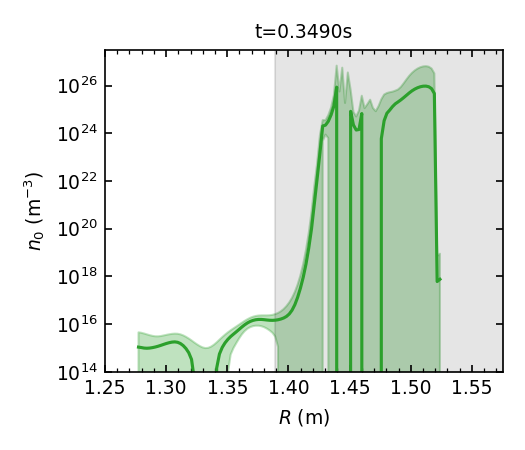

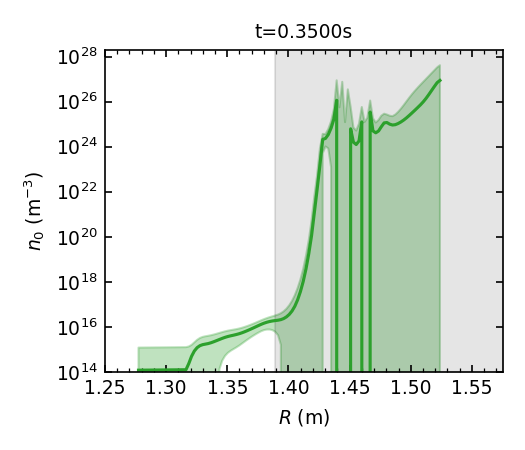

In [16]:
twants = [0.344,0.345,0.346,0.347,0.348,0.349,0.350,]
for twant in twants:
    plotN(twant)

/tmp/ipykernel_21489/1531044576.py:35: UserWarning: AutoMinorLocator does not work with logarithmic scale
  plt.tight_layout()


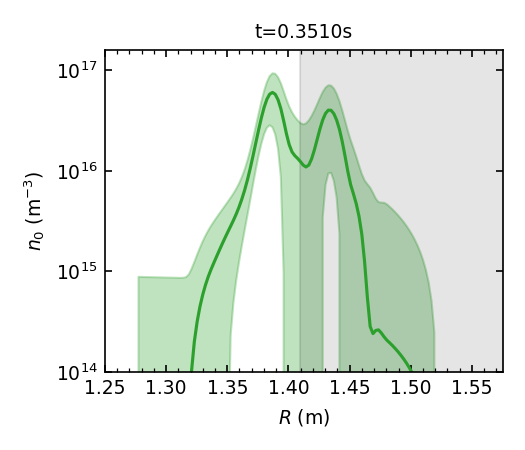

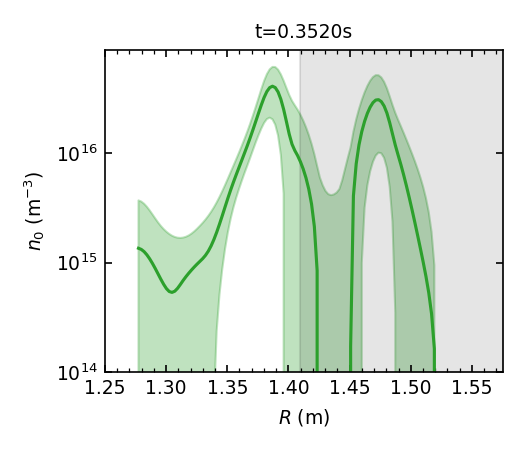

In [17]:
twant = 0.351
plotN(twant)
twant = 0.352
plotN(twant)

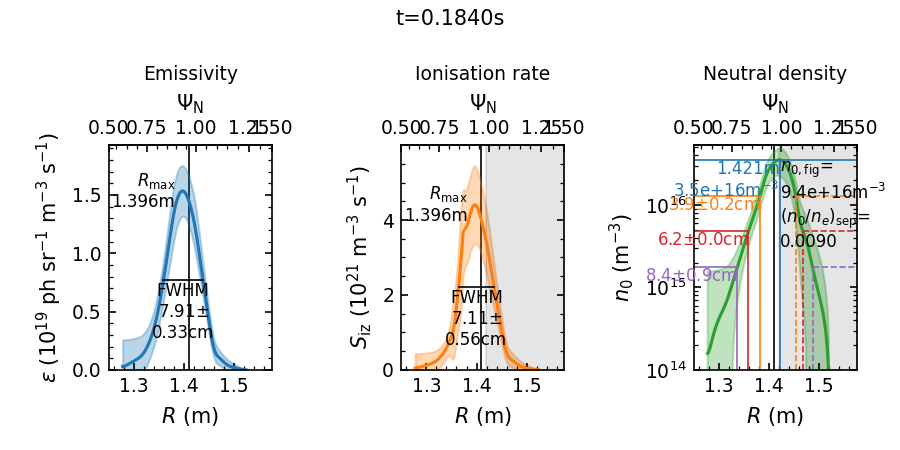

In [19]:
result(0.184, results)

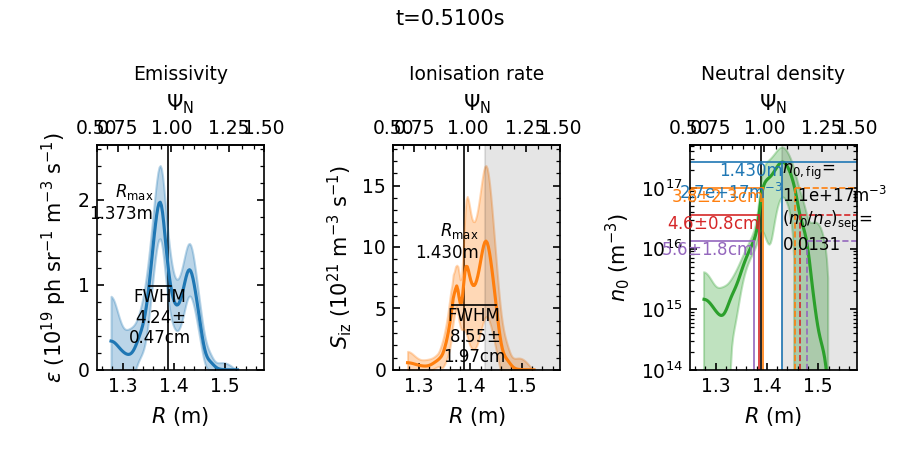

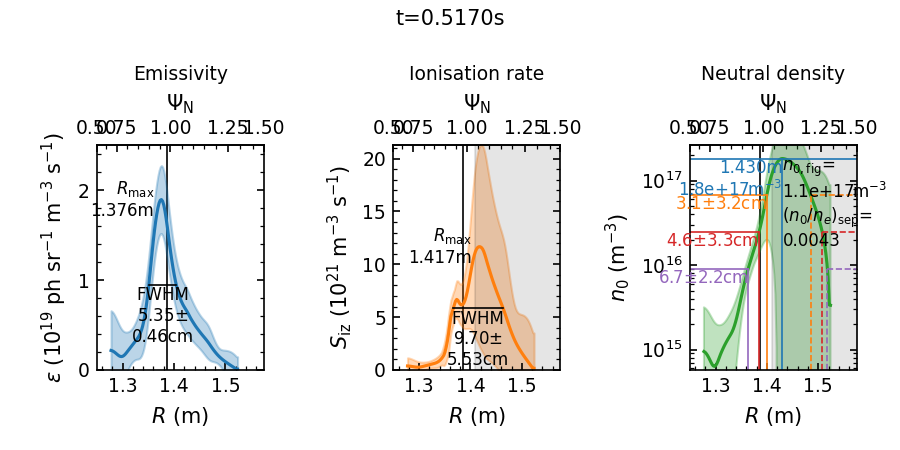

In [21]:
result(0.510, results)
result(0.517, results)

/tmp/ipykernel_12601/2249658252.py:34: UserWarning: AutoMinorLocator does not work with logarithmic scale
  plt.tight_layout()


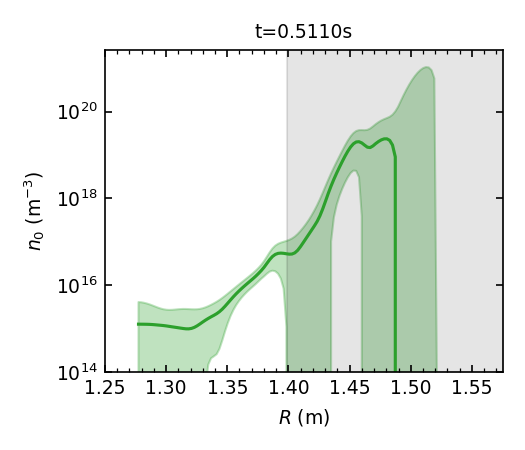

In [66]:
twant = 0.511



plotN(twant)

/tmp/ipykernel_12601/1531044576.py:35: UserWarning: AutoMinorLocator does not work with logarithmic scale
  plt.tight_layout()


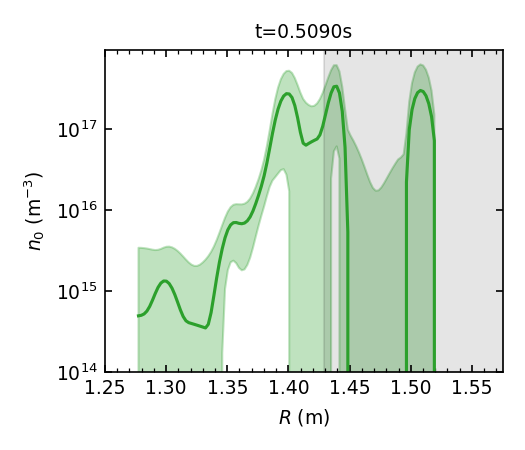

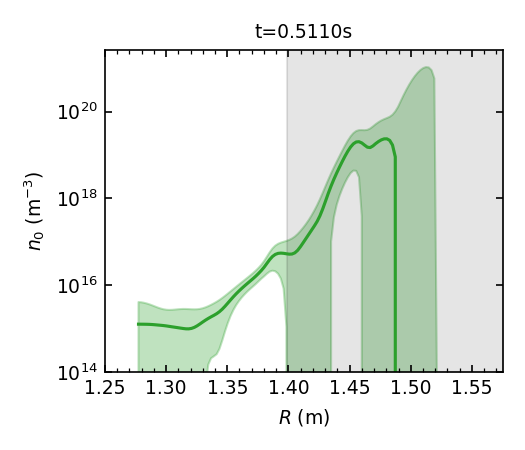

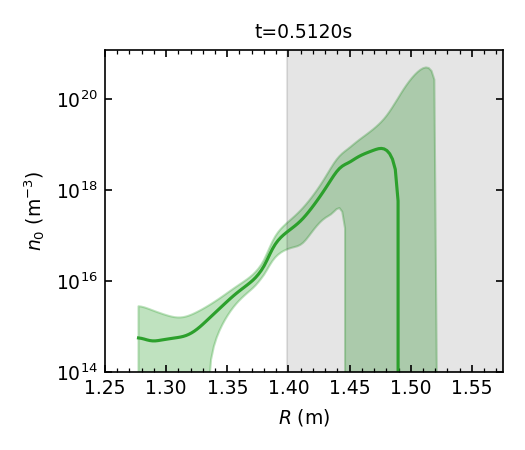

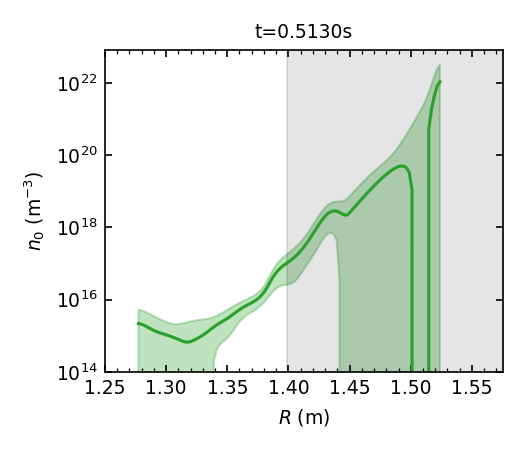

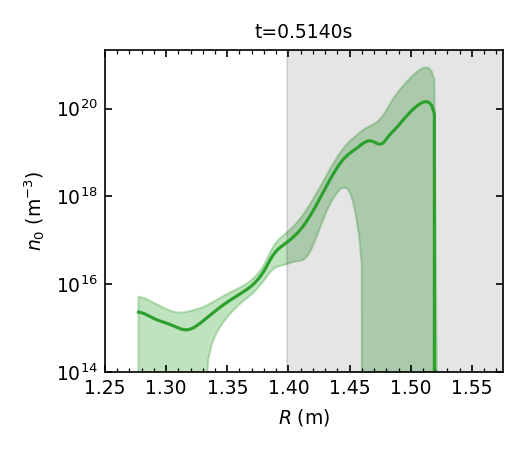

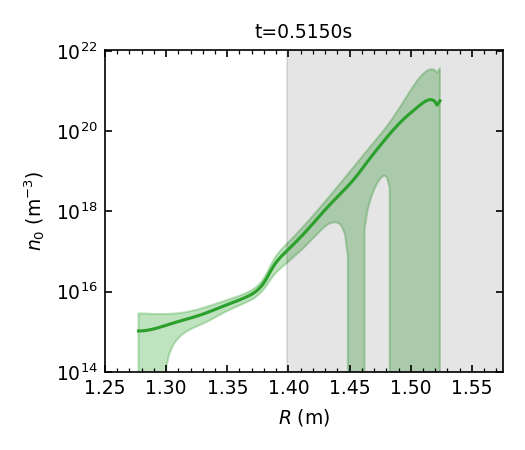

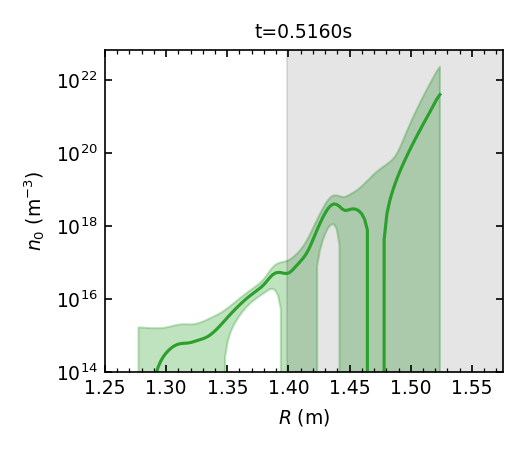

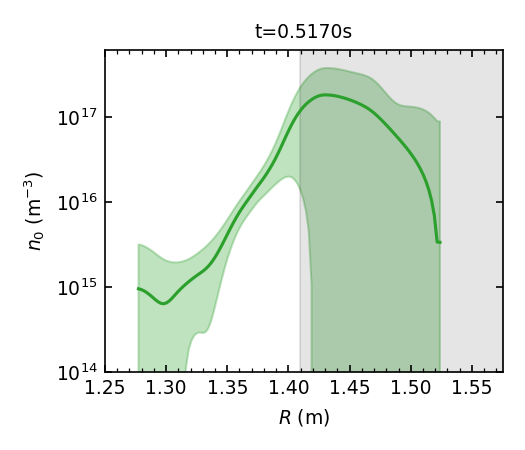

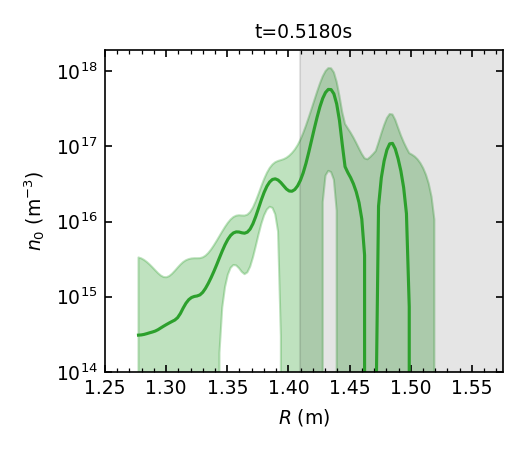

In [74]:
twants = [0.509, 0.510, 0.511, 0.512, 0.513, 0.514, 0.515, 0.516, 0.517, 0.518]
for twant in twants:
    plotN(twant)

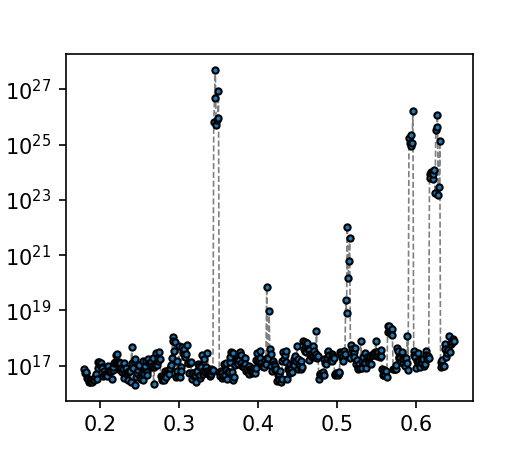

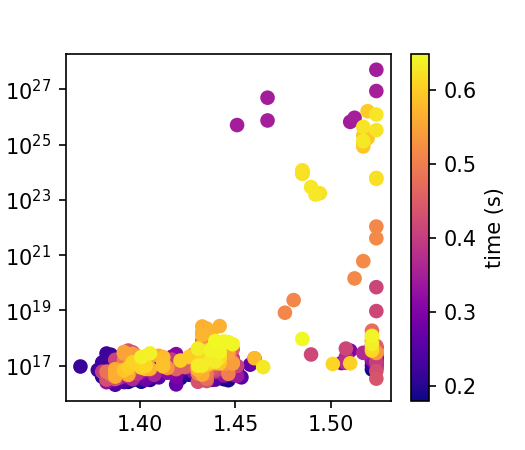

In [12]:



fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(xn0, yn0, '--', c='gray', lw=0.8)
ax.plot(xn0[maskn0], yn0[maskn0], '.', c='C0', mec='k')
ax.set_yscale('log')




fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
sc=ax.scatter(
    neutralMaxR[tind0:tind1], neutralMax[tind0:tind1], 
    c=time[tind0:tind1], cmap=plt.cm.plasma
)
cbar=fig.colorbar(sc, ax=ax, label='time (s)')
ax.set_yscale('log')



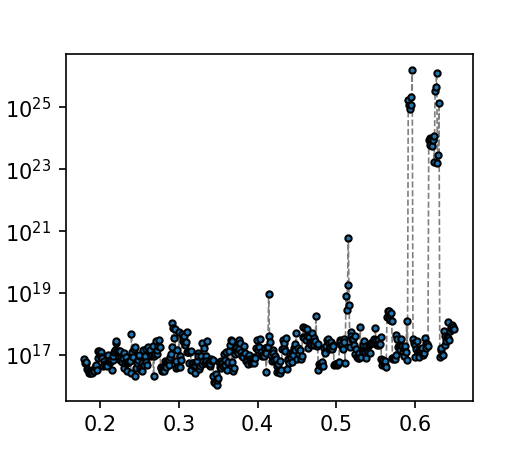

In [27]:
n0 = neutralMax.copy()

n0[164] = 2.13e16
n0[165] = 1.31e16
n0[166] = 1.28e16
n0[167] = 2.49e16
n0[168] = 1.09e16
n0[169] = 1.58e16
n0[170] = 1.77e16

n0[231] = 2.91e16

n0[331] = 5.49e16
n0[333] = 2.88e18
n0[334] = 1.85e19
# n0[335] = e18
n0[336] = 4.08e18

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(time, n0, '--', c='gray', lw=0.8)
ax.plot(time, n0, '.', c='C0', mec='k')
ax.set_yscale('log')

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
# ax.plot(dar.time.data, dar.data, c='C0', label='Radial')
# ax.plot(dat.time.data, dat.data, c='C1', label='Tang.')
# ax.plot(daUOSP.time.data, daUOSP.data, c='C2', label='U OSP')
ax.plot(daLOSP.time.data, daLOSP.data, c='C3', label='L OSP')
# ax.plot(daUSXD.time.data, daUSXD.data, c='C4', label='U SXD')
# ax.plot(daLSXD.time.data, daLSXD.data, c='C5', label='L SXD')

ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('time (s)')
ax.set_ylabel('D$_\\alpha$ (V)')
ax.set_xlim([-0.1,1.3])
plt.tight_layout()

In [ ]:
bp.plotSXR(shotn, )

In [ ]:
thomsonTime, ne, neErr, Rthomson = HSV.getThomson(shotn, 'n_e')
_, Te, TeErr, _ = HSV.getThomson(shotn, 'T_e')

In [ ]:
i = 200
I = HSV.findNearest(thomsonTime, time[i])
rind = HSV.findNearest(Rthomson[I], 1.25)

fig, ax = plt.subplots(1, 2, figsize=(5,3), dpi=150, sharex=True)

ax[0].errorbar(Rthomson[I], ne[I], yerr=neErr[I], c='C0', fmt='None', capsize=4)
ax[0].plot(Rprofile, profileDensity[i], '--k')
ax[0].set_xlabel('$R$ (m)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_ylim([0, ne[I,rind:][np.isfinite(ne[I,rind:])].max()*1.1])

ax[1].errorbar(Rthomson[I], Te[I], yerr=TeErr[I], c='C3', fmt='None', capsize=4)
ax[1].plot(Rprofile, profileTemp[i], '--k')
ax[1].set_xlabel('$R$ (m)')
ax[1].set_ylabel('$T_e$ (eV)')
ax[1].set_ylim([0, Te[I,rind:][np.isfinite(Te[I,rind:])].max()*1.1])

ax[0].set_xlim([1.25, 1.50])

fig.suptitle(f'shot # {shotn}, t={time[i]:.4f}s')
plt.tight_layout()

In [ ]:
def plotSignals(shotn):
    sigs = mf.getFuelSignals(shotn)
    fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
    for i, sig in enumerate(sigs):
        data = client.get(sig, shotn)
        ax.plot(data.time.data, data.data, label=sig)
    ax.set_xlabel('time (s)', fontsize=9)
    ax.set_ylabel('fuel (V)', fontsize=9)
    ax.legend(fancybox=1 ,framealpha=1, fontsize=8)
    ax.set_title(f'shot # {shotn}', fontsize=9)
    ax.tick_params(
        axis="both", which='both', labelsize=9, direction='in', 
        left=True, bottom=True, right=True, top=True
    )
    ax.set_xlim([-0.1,1.4])
    plt.tight_layout()
    return fig, ax

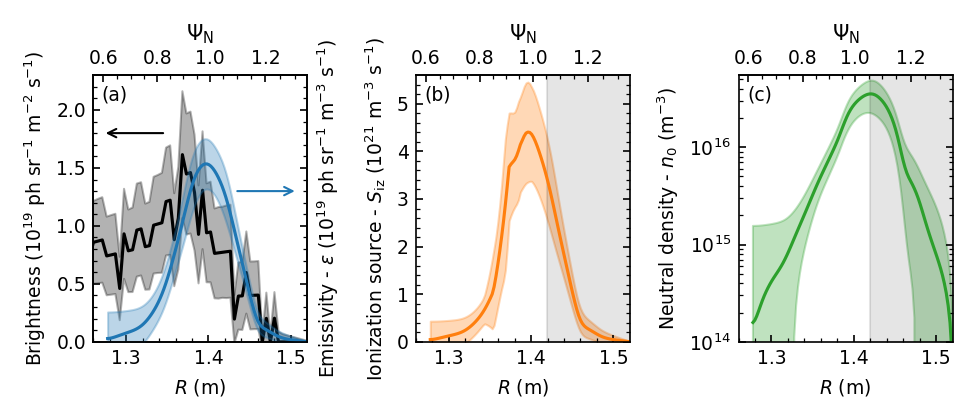

In [155]:
#### for proposal
def result2(twant, npz):
    ### load the results
    data = results['data']
    err = results['err']
    RgridB = results['R']
    Rprofile = results['Rprofile']
    time = results['time']
    emissivity = results['emissivity']
    emissivityErr = results['emissivityErr']
    emMax = results['emMax']
    emMaxR = results['emMaxR']
    emR0 = results['emR0']
    emR1 = results['emR1']
    emFWHM = results['emFWHM']
    emFWHMerr = results['emFWHMerr']
    Rind = results['Rind']
    RendThomson = results['RendThomson']
    ioniseRate = results['ioniseRate']
    ioniseErr = results['ioniseErr']
    neutralDensity = results['neutralDensity']
    neutralErr = results['neutralErr']
    ioniseMax = results['ioniseMax']
    ioniseMaxR = results['ioniseMaxR']
    ioniseR0 = results['ioniseR0']
    ioniseR1 = results['ioniseR1']
    ioniseFWHM = results['ioniseFWHM']
    ioniseFWHMerr = results['ioniseFWHMerr']
    neutralMax = results['neutralMax']
    neutralMaxR = results['neutralMaxR']
    neutralR1 = results['neutralR1']
    neutralR2 = results['neutralR2']
    neutralR3 = results['neutralR3']
    neutralWidth1 = results['neutralWidth1']
    neutralWidth1err = results['neutralWidth1err']
    neutralWidth2 = results['neutralWidth2']
    neutralWidth2err = results['neutralWidth2err']
    neutralWidth3 = results['neutralWidth3']
    neutralWidth3err = results['neutralWidth3err']
    neutralR1A = results['neutralR1A']
    neutralR2A = results['neutralR2A']
    neutralR3A = results['neutralR3A']
    R = results['R']
    mask = results['mask']
    figN0 = results['figN0']
    psiN = results['psiN']
    neutralRatio = results['neutralRatio']
    
    I = pf.findNearest(time, twant)
    J = I + 1
            
    fills = pf.makeFills(mask, R)
    ### call the plotting function
    fig, ax = plotResults(data[I:J], err[I:J], RgridB, 
        Rprofile, emissivity[I:J,Rind:], emissivityErr[I:J,Rind:], 
        emMaxR[I:J], emMax[I:J], emR0[I:J], emR1[I:J], emFWHM[I:J], 
        emFWHMerr[I:J], ioniseRate[I:J], ioniseErr[I:J], ioniseMax[I:J], 
        ioniseMaxR[I:J], ioniseR0[I:J], ioniseR1[I:J], ioniseFWHM[I:J], 
        ioniseFWHMerr[I:J], neutralDensity[I:J], neutralErr[I:J], 
        neutralMax[I:J], neutralMaxR[I:J], neutralR1[I:J], neutralR2[I:J], 
        neutralR3[I:J], neutralWidth1[I:J], neutralWidth1err[I:J], 
        neutralWidth2[I:J], neutralWidth2err[I:J], neutralWidth3[I:J], 
        neutralWidth3err[I:J], neutralR1A[I:J], neutralR2A[I:J], 
        neutralR3A[I:J], RendThomson[I:J], time[I:J], fills[I:J], 
        figN0=figN0[I:J], neutralRatio=neutralRatio[I:J], psiN=psiN[I:J], 
        savePath='./', close=False
    )
    return fig, ax 

### function for plotting emissivity, Siz, and n0
def plotResults(data, err, RgridB, 
    R, emiss, emissErr, emMaxR, emMax, emR0, emR1, emFWHM, emFWHMerr, Siz,
    SizErr, SizMax, SizMaxR, SizR0, SizR1, SizFWHM, SizFWHMerr, n0, n0Err,
    n0Max, n0MaxR, n0R1, n0R2, n0R3, n0w1, n0w1err, n0w2, n0w2err, n0w3, 
    n0w3err, n0R1A, n0R2A, n0R3A, Rend, time, fills, figN0=None, neutralRatio=None, 
    psiN=None, yMult=1.1, xlim=[1.26,1.52], n0lim=1e14, savePath=None, 
    close=False
    ):
    Rind = pf.findNearest(R, xlim[1])
    if psiN is None:
        top = True
    else:
        top = False
    for i in range(len(time)):
        Rind1 = pf.findNearest(R, Rend[i])
        fig, ax = plt.subplots(1, 3, figsize=(6.5,2.8), dpi=150)
        
        ax[0].plot(RgridB, data[i]/1e19, '-', c='k')
        ax[0].fill_between(
            RgridB, data[i]/1e19-err[i]/1e19, 
            data[i]/1e19+err[i]/1e19, color='k', alpha=0.3
        )
        
        ax2 = ax[0].twinx()
        ax2.plot(R, emiss[i]/1e19, '-', c='C0')
        ax2.fill_between(
            R, emiss[i]/1e19-emissErr[i]/1e19, 
            emiss[i]/1e19+emissErr[i]/1e19, color='C0', alpha=0.3
        )
#         ax[0].plot(
#             [emR0[i], emR1[i]], [emMax[i]/2./1e19, emMax[i]/2./1e19], 
#             '-k', lw=0.8
#         )
#         ax[0].text(
#             emMaxR[i]*0.99, emMax[i]/1e19, 
#             f'$R_\\mathrm{{max}}$\n{emMaxR[i]:.3f}m',
#             ha='right', va='center', fontsize=8
#         )
#         ax[0].text(
#             (emR0[i]+emR1[i])/2., 0.98*emMax[i]/2./1e19, 
#             f'FWHM\n{emFWHM[i]*100:.2f}$\\pm$\n{emFWHMerr[i]*100:.2f}cm', 
#             ha='center', va='top', fontsize=8
#         )
#         ax[0].set_title('Emissivity', fontsize=9)
        ax[0].set_xlabel('$R$ (m)', fontsize=9)
        ax[0].set_ylabel(
            'Brightness (10$^{19}$ ph sr$^{-1}$ m$^{-2}$ s$^{-1}$)', fontsize=9
        )
        ax2.set_ylabel(
            'Emissivity - $\\epsilon$ (10$^{19}$ ph sr$^{-1}$ m$^{-3}$ s$^{-1}$)', fontsize=9
        )
        ax2.set_yticks([])
        ax[0].yaxis.get_offset_text().set_size(9)
#         ax[0].set_ylim([0., (emiss[i]+emissErr[i]).max()/1e19 * 1.3])
        ax[0].set_ylim([0., 2.3])
        ax2.set_ylim([0., 2.3])
        ylim = ax[0].get_ylim()
        for j in range(0, fills.shape[0]):
            ax[0].fill_between(
                fills[j], [ylim[0],ylim[0]], 
                [ylim[1],ylim[1]], color='C3', alpha=0.1
            )
        ax[0].yaxis.set_minor_locator(AutoMinorLocator())
        
        ax[1].plot(R, Siz[i]/1e21, '-', c='C1')
        ax[1].fill_between(
            R, Siz[i]/1e21-SizErr[i]/1e21, 
            Siz[i]/1e21+SizErr[i]/1e21, color='C1', alpha=0.3
        )
#         ax[1].plot(
#             [SizR0[i], SizR1[i]], [SizMax[i]/2./1e21, SizMax[i]/2./1e21], 
#             '-k', lw=0.8
#         )
#         ax[1].text(
#             SizMaxR[i]*0.99, SizMax[i]/1e21, 
#             f'$R_\\mathrm{{max}}$\n{SizMaxR[i]:.3f}m', 
#             ha='right', va='center', fontsize=8
#         )
#         ax[1].text(
#             (SizR0[i]+SizR1[i])/2., 0.98*SizMax[i]/2./1e21, 
#             f'FWHM\n{SizFWHM[i]*100:.2f}$\\pm$\n{SizFWHMerr[i]*100:.2f}cm', 
#             ha='center', va='top', fontsize=8
#         )
        
#         ax[1].set_title('Ionisation rate', fontsize=9)
        ax[1].set_xlabel('$R$ (m)', fontsize=9)
        ax[1].set_ylabel('Ionization source - $S_\\mathrm{iz}$ (10$^{21}$ m$^{-3}$ s$^{-1}$)', fontsize=9)
        ax[1].yaxis.get_offset_text().set_size(9)
#         ylim = [0., (Siz[i,:Rind1+1]+SizErr[i,:Rind1+1]).max()/1e21 * yMult]
        ylim = [0., 5.6]
        ax[1].fill_between(
            [Rend[i],xlim[1]], [ylim[0],ylim[0]], 
            [ylim[1],ylim[1]], color='k', alpha=0.1
            )
        ax[1].set_ylim(ylim)
        for j in range(0, fills.shape[0]):
            ax[1].fill_between(
                fills[j], [ylim[0],ylim[0]], 
                [ylim[1],ylim[1]], color='C3', alpha=0.1
            )
        ax[1].yaxis.set_minor_locator(AutoMinorLocator())
        
        ax[2].plot(R, n0[i], '-', c='C2', mfc='None')
        ax[2].fill_between(
            R, n0[i]-n0Err[i], n0[i]+n0Err[i], color='C2', alpha=0.3
        )
#         ylim = [
#             np.max((n0[i,:Rind].min() / yMult, n0lim)), 
#             (n0[i,:Rind1+1] + n0Err[i,Rind1+1]).max() * yMult
#         ]
        ylim = [1e14, 5.5e16]
#         ax[2].plot(xlim, [n0Max[i],n0Max[i]], '-', c='C0', lw=0.8)
#         ax[2].plot(
#             [n0MaxR[i],n0MaxR[i]], [ylim[0],n0Max[i]], '-', c='C0', lw=0.8
#         )
#         ax[2].text(
#             n0MaxR[i], n0Max[i], 
#             f'{n0MaxR[i]:.3f}m\n{n0Max[i]:.2g}m$^{{-3}}$', 
#             c='C0', fontsize=8, ha='right', va='top'
#         )

#         yVal = n0Max[i] * np.exp(-1.)
#         ax[2].plot([xlim[0],n0R1[i]], [yVal,yVal], '-', c='C1', lw=0.8)
#         ax[2].plot([n0R1[i],n0R1[i]], [ylim[0],yVal], '-', c='C1', lw=0.8)
#         ax[2].text(
#             n0R1[i], yVal, 
#             f'{n0w1[i]*100.:.1f}$\\pm${n0w1err[i]*100.:.1f}cm', 
#             c='C1', fontsize=8, ha='right', va='top'
#         )
#         ax[2].plot([n0R1A[i],xlim[1]], [yVal,yVal], '--', c='C1', lw=0.8)
#         ax[2].plot([n0R1A[i],n0R1A[i]], [ylim[0],yVal], '--', c='C1', lw=0.8)
#         yVal = n0Max[i] * np.exp(-2.)
#         ax[2].plot([xlim[0],n0R2[i]], [yVal,yVal], '-', c='C3', lw=0.8)
#         ax[2].plot([n0R2[i],n0R2[i]], [ylim[0],yVal], '-', c='C3', lw=0.8)
#         ax[2].text(
#             n0R2[i], yVal, 
#             f'{n0w2[i]*100.:.1f}$\\pm${n0w2err[i]*100.:.1f}cm', 
#             c='C3', fontsize=8, ha='right', va='top'
#         )
#         ax[2].plot([n0R2A[i],xlim[1]], [yVal,yVal], '--', c='C3', lw=0.8)
#         ax[2].plot([n0R2A[i],n0R2A[i]], [ylim[0],yVal], '--', c='C3', lw=0.8)
#         yVal = n0Max[i] * np.exp(-3.)
#         ax[2].plot([xlim[0],n0R3[i]], [yVal,yVal], '-', c='C4', lw=0.8)
#         ax[2].plot([n0R3[i],n0R3[i]], [ylim[0],yVal], '-', c='C4', lw=0.8)
#         ax[2].text(
#             n0R3[i], yVal, 
#             f'{n0w3[i]*100.:.1f}$\\pm${n0w3err[i]*100.:.1f}cm', 
#             c='C4', fontsize=8, ha='right', va='top'
#         )
#         ax[2].plot([n0R3A[i],xlim[1]], [yVal,yVal], '--', c='C4', lw=0.8)
#         ax[2].plot([n0R3A[i],n0R3A[i]], [ylim[0],yVal], '--', c='C4', lw=0.8)
#         ax[2].set_title('Neutral density', fontsize=9)
        ax[2].set_xlabel('$R$ (m)', fontsize=9)
        ax[2].set_ylabel('Neutral density - $n_0$ (m$^{-3}$)', fontsize=9)
        ax[2].yaxis.get_offset_text().set_size(9)
        ax[2].set_ylim(ylim)
        ax[2].fill_between(
            [Rend[i],xlim[1]], [ylim[0],ylim[0]], 
            [ylim[1],ylim[1]], color='k', alpha=0.1
            )
        ax[2].set_yscale('log')
        for j in range(0, fills.shape[0]):
            ax[2].fill_between(
                fills[j], [ylim[0],ylim[0]], 
                [ylim[1],ylim[1]], color='C3', alpha=0.1
            )

#         if neutralRatio is not None:
#             ax[2].text(
#                 n0MaxR[i], n0Max[i], 
#                 f'$n_{{0,\\mathrm{{fig}}}}$=\n{figN0[i]:.2g}m$^{{-3}}$\n' + \
#                 f'$(n_0/n_e)_\\mathrm{{sep}}$=\n{neutralRatio[i]:.4f}', 
#                 color='k', fontsize=8, va='top', ha='left'
#             )
#         elif figN0 is not None:
#             ax[2].text(
#                 n0MaxR[i], n0Max[i], 
#                 f'$n_{{0,\\mathrm{{fig}}}}$=\n{figN0[i]:.2g}m$^{{-3}}$\n', 
#                 color='k', fontsize=8, va='top', ha='left'
#             )
            
        for j in range(3):
            ax[j].set_xlim(xlim)
            ax[j].tick_params(
                axis="both", which='both', labelsize=9, direction='in', 
                left=True, bottom=True, right=True, top=top
            )
            ax[j].xaxis.set_minor_locator(AutoMinorLocator())
            if not top:
                def forward(x):
                    return np.interp(x, R, psiN[i])
                def inverse(x):
                    return np.interp(x, psiN[i], R)
                sepR = np.interp(1., psiN[i], R)
                
                secax = ax[j].secondary_xaxis(
                    'top', functions=(forward, inverse)
                )
                secax.set_xticks([0.6,0.8,1.,1.2,1.4])
#                 secax.xaxis.set_minor_locator(AutoMinorLocator())
                secax.set_xlabel('$\\Psi_\\mathrm{N}$')
                secax.tick_params(
                    axis="both", which='both', labelsize=9, direction='in', 
                            left=False, bottom=False, right=False, top=True
                )
                secax.minorticks_on()
                ylim = ax[j].get_ylim()
#                 ax[j].plot([sepR, sepR], ylim, '-k', lw=0.8, zorder=0)
        
#         fig.suptitle(f't={time[i]:.4f}s', fontsize=10)
        ax2.tick_params(
                axis="both", which='both', labelsize=9, direction='in', 
                left=False, bottom=False, right=False, top=False
            )
    
    
        ###
#         xx00 = 0.09
#         dx1 = 0.2
#         dx2 = 0.15
#         dx3 = 0.10
#         yy00 = 0.13
#         dy = 0.88 - yy00
#         ax[0].set_position([xx00, yy00, dx1, dy])
#         ax[1].set_position([xx00+dx1+dx2, yy00, dx1, dy])
#         ax[2].set_position([xx00+dx1+dx2+dx1+dx3, yy00, dx1, dy])

        ax[0].annotate(
            '', xy=(1.27, 1.8), xytext=(1.35, 1.8), 
            arrowprops=dict(arrowstyle='->', color='k',)
        )
        ax[0].annotate(
            '', xy=(1.51, 1.3), xytext=(1.43, 1.3), 
            arrowprops=dict(arrowstyle='->', color='C0',)
        )
        bbox = dict(facecolor='None', edgecolor='None', boxstyle=None)
        xbox = 0.04
        ybox = 0.96
        ax[0].text(xbox, ybox, '(a)', ha='left', va='top', transform=ax[0].transAxes, bbox=bbox, fontsize=9)
        ax[1].text(xbox, ybox, '(b)', ha='left', va='top', transform=ax[1].transAxes, bbox=bbox, fontsize=9)
        ax[2].text(xbox, ybox, '(c)', ha='left', va='top', transform=ax[2].transAxes, bbox=bbox, fontsize=9)
        
        plt.tight_layout()
        if savePath:
            plt.savefig(savePath + f'{time[i]:.4f}s.png')
        if close:
            plt.close()
    return fig, ax

fig, ax = result2(0.184, results)

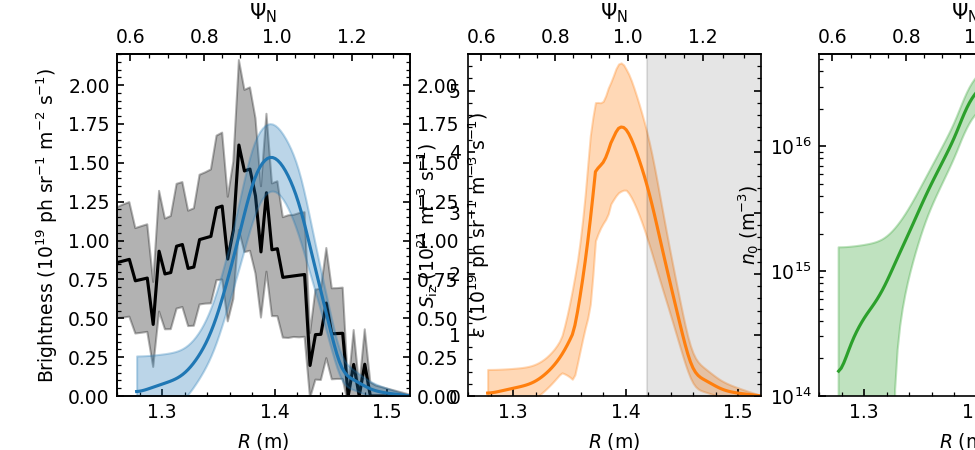

In [128]:
fig, ax = result2(0.184, results)
# ax[0].set_ylabel('Brightness ()\nEmissivity ()', fontsize=9)
# ax[0].set_ylabel('', fontsize=9)
# ax[0].text(
#     -0.32, 0.5, 'Brightness (10$^{19}$ ph sr$^{-1}$ m$^{-2}$ s$^{-1}$)', transform=ax[0].transAxes,
#     ha='right', va='center', color='k', fontsize=9, rotation=90
# )
# ax[0].text(
#     -0.21, 0.5, 'Emissivity - $\\epsilon$ (10$^{19}$ ph sr$^{-1}$ m$^{-3}$ s$^{-1}$)', transform=ax[0].transAxes,
#     ha='right', va='center', color='C0', fontsize=9, rotation=90
# )

In [124]:
0.88-0.12

0.76

In [123]:
ax[0].get_position(), ax[1].get_position(), ax[2].get_position()


(Bbox([[0.125, 0.10999999999999999], [0.3529411764705882, 0.88]]),
 Bbox([[0.3985294117647059, 0.10999999999999999], [0.6264705882352941, 0.88]]),
 Bbox([[0.6720588235294118, 0.10999999999999999], [0.9, 0.88]]))

Text(-0.1, 0.5, 'Emissivity ()')

In [98]:
eq.psiN(1.2824, 0.)

array([[0.58072682]])

In [65]:
from pyEquilibrium.equilibrium import equilibrium as equil


In [84]:
eq = equil(device='MASTU', shot=shotn, time=0.184)
eq2= equil(device='MASTU', shot=shotn, time=0.184, mastu_prefix='epm')

In [74]:
Rprofile

array([1.27744653, 1.27972813, 1.28200973, 1.28429133, 1.28657293,
       1.28885453, 1.29113613, 1.29341773, 1.29569932, 1.29798092,
       1.30026252, 1.30254412, 1.30482572, 1.30710732, 1.30938892,
       1.31167052, 1.31395211, 1.31623371, 1.31851531, 1.32079691,
       1.32307851, 1.32536011, 1.32764171, 1.32992331, 1.3322049 ,
       1.3344865 , 1.3367681 , 1.3390497 , 1.3413313 , 1.3436129 ,
       1.3458945 , 1.3481761 , 1.35045769, 1.35273929, 1.35502089,
       1.35730249, 1.35958409, 1.36186569, 1.36414729, 1.36642889,
       1.36871048, 1.37099208, 1.37327368, 1.37555528, 1.37783688,
       1.38011848, 1.38240008, 1.38468168, 1.38696327, 1.38924487,
       1.39152647, 1.39380807, 1.39608967, 1.39837127, 1.40065287,
       1.40293447, 1.40521606, 1.40749766, 1.40977926, 1.41206086,
       1.41434246, 1.41662406, 1.41890566, 1.42118726, 1.42346885,
       1.42575045, 1.42803205, 1.43031365, 1.43259525, 1.43487685,
       1.43715845, 1.43944005, 1.44172165, 1.44400324, 1.44628

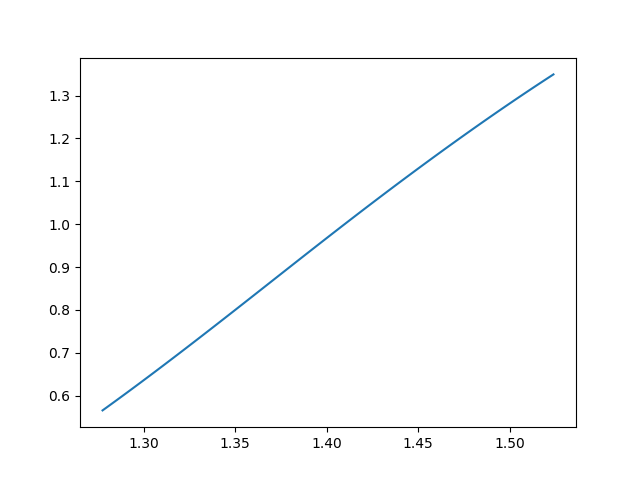

In [73]:
plt.figure()
plt.plot(Rprofile, eq.psiN(Rprofile, 0.)[0])